# 1. Data Manager

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os

class DataManager:
    # Khởi tạo
    def __init__(self, ground_truth_path: str, features_path: str, batch_size=64):
        self.ground_truth_path = ground_truth_path
        self.features_path = features_path
        self.batch_size = batch_size
        
        self.embeddings = None
        self.noisy_labels = None  
        self.true_labels = None   
        self.num_classes = None
        
        # Các tensor sẽ được khởi tạo
        self.X_tensor = None
        self.y_noisy_tensor = None # Sẽ là soft labels (N, C)
        self.y_true_tensor = None

        self._load_and_process_data() # Tải data khi init
        self._prepare_pytorch_tensors() # chuẩn bị data

    def _load_and_process_data(self):
        print("Bắt đầu quá trình Load & Process Data...")

        # Đọc ground_truth path, đổi tên label -> true_labels (để đánh giá)
        df_csv = pd.read_csv(self.ground_truth_path)
        df_csv.rename(columns={'label': 'true_label'}, inplace=True)

        # Đọc feather_path (embeddings & noise label -> để tên là label)
        df_feather = pd.read_feather(self.features_path)

        # Ghép
        df_aligned = pd.concat([df_feather, df_csv[['true_label']]], axis=1)

        self.noisy_labels = df_aligned['label'].values.astype(int)
        self.true_labels = df_aligned['true_label'].values.astype(int)
        
        embedding_df = df_aligned.drop(columns=['label', 'true_label'])
        self.embeddings = embedding_df.values
        
        print(f"✅ Thành công Load & Process Data.")
        print(f"Tổng số mẫu xử lý: {len(self.embeddings)}")
        print(f"Kích thước embedding (số chiều): {self.embeddings.shape[1]}")

    def _prepare_pytorch_tensors(self):
        if self.num_classes is None: # Chỉ tính một lần
             self.num_classes = len(np.unique(self.true_labels))
             print(f"Số lượng lớp: {self.num_classes}")
        
        self.X_tensor = torch.tensor(self.embeddings, dtype=torch.float32)
        self.y_true_tensor = torch.tensor(self.true_labels, dtype=torch.long) # Nhãn thật không thay đổi
        
        # Chuyển nhãn nhiễu ban đầu (dạng cứng) sang dạng one-hot (dạng mềm)
        noisy_labels_one_hot = np.eye(self.num_classes)[self.noisy_labels]
        self.y_noisy_tensor = torch.tensor(noisy_labels_one_hot, dtype=torch.float32)

    def update_noisy_soft_labels(self, new_soft_labels: np.ndarray):
        """
        Cập nhật nhãn nhiễu bằng "soft labels" mới cho vòng lặp tiếp theo.
        """
        print("\n🔄 Cập nhật soft labels cho vòng lặp tiếp theo...")
        if new_soft_labels.shape != (len(self.embeddings), self.num_classes):
            raise ValueError(f"Shape của Soft Lables không chính xác! Expecting {(len(self.embeddings), self.num_classes)}, got {new_soft_labels.shape}")
        
        # Cập nhật trực tiếp tensor nhãn nhiễu với soft labels mới
        self.y_noisy_tensor = torch.tensor(new_soft_labels, dtype=torch.float32)
        
        # Cập nhật cả phiên bản nhãn cứng (để tiện cho việc đánh giá và so sánh)
        self.noisy_labels = np.argmax(new_soft_labels, axis=1)
        print("✅ Soft label updated sucessfull!")

    def get_full_dataset(self):
        return TensorDataset(self.X_tensor, self.y_noisy_tensor, self.y_true_tensor)

    def get_full_dataloader(self, shuffle=True):
        dataset = self.get_full_dataset()
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle, drop_last=True)

# 2. Model Architectures

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    """
    MLP model 
    """
    def __init__(self, input_dim, num_classes, hidden_dims=[1024, 512, 256]):
        super(MLP, self).__init__()
        
        layers = []
        current_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # <<-- BATCH NORM
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.5))
            current_dim = h_dim
            
        layers.append(nn.Linear(current_dim, num_classes))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# 3. Utils


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

def set_seed(seed):
    """Thiết lập seed cho tính tái lập."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
# Hai hàm này chỉ dùng để đánh giá, không dùng trong pipeline.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_ground_truth_T(true_labels, noisy_labels, num_classes):
    """
    Tính toán ma trận chuyển đổi nhiễu "chuẩn" từ nhãn thật và nhãn nhiễu.
    """
    T_true = np.zeros((num_classes, num_classes))
    for i in range(num_classes):
        # Lấy chỉ số của các mẫu có nhãn thật là `i`
        indices = np.where(true_labels == i)[0]
        if len(indices) == 0:
            continue
        
        # Lấy các nhãn nhiễu tương ứng
        noisy_subset = noisy_labels[indices]
        
        # Đếm tần suất của mỗi nhãn nhiễu `j`
        for j in range(num_classes):
            T_true[i, j] = np.sum(noisy_subset == j) / len(indices)
            
    return T_true

def evaluate_T_matrix(T_estimated, T_true):
    """
    Đánh giá ma trận T ước tính bằng MAE và vẽ heatmap so sánh.
    """
    # 1. Tính MAE
    mae = np.mean(np.abs(T_true - T_estimated))
    print(f"📊 Sai số tuyệt đối trung bình (MAE) giữa T_estimated và T_true: {mae:.4f}")
    print("   (Giá trị càng gần 0 càng tốt)")

    # 2. Vẽ Heatmap để so sánh
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(T_estimated, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
    axes[0].set_title('Ma trận T Ước tính (T_estimated)', fontsize=14)
    axes[0].set_xlabel('Nhãn Nhiễu')
    axes[0].set_ylabel('Nhãn Sạch (ước tính)')
    
    sns.heatmap(T_true, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
    axes[1].set_title('Ma trận T Ground Truth (T_true)', fontsize=14)
    axes[1].set_xlabel('Nhãn Nhiễu')
    axes[1].set_ylabel('Nhãn Sạch (thực tế)')
    
    plt.tight_layout()
    plt.show()

In [5]:
class EarlyStopper:
    """Dừng sớm quá trình huấn luyện khi loss không cải thiện."""
    def __init__(self, patience=10, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, loss):
        if self.best_loss - loss > self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print(f"🛑 Dừng sớm! Loss không cải thiện trong {self.patience} epochs.")
                return True
        return False

# 4. Pipeline

## 4.1. Co-training bước đầu tiên

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class ACTTrainer:
    def __init__(self, input_dim, num_classes, hidden_dims=[512, 256], lr_rtm=1e-4, lr_ntm=1e-3):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.num_classes = num_classes
        
        self.rtm = MLP(input_dim, num_classes, hidden_dims).to(self.device)
        self.ntm = MLP(input_dim, num_classes, hidden_dims).to(self.device)
        
        self.optimizer_rtm = optim.Adam(self.rtm.parameters(), lr=lr_rtm)
        self.optimizer_ntm = optim.Adam(self.ntm.parameters(), lr=lr_ntm)
        
        self.criterion = nn.CrossEntropyLoss()

    def train(self, dataloader, epochs=100, warmup_epochs=20, early_stopper=None):        
        full_dataset = dataloader.dataset
        X_full = full_dataset.tensors[0].to(self.device)
        y_noisy_full_soft = full_dataset.tensors[1].to(self.device) # Đây là soft labels (N, C)

        for epoch in range(epochs):
            self.rtm.train()
            self.ntm.train()
            
            # Giai đoạn Warm-up
            if epoch < warmup_epochs:
                for features, noisy_labels_soft, _ in dataloader:
                    features, noisy_labels_soft = features.to(self.device), noisy_labels_soft.to(self.device)
                    # Cập nhật RTM
                    self.optimizer_rtm.zero_grad()
                    loss_rtm = self.criterion(self.rtm(features), noisy_labels_soft)
                    loss_rtm.backward()
                    self.optimizer_rtm.step()
                    # Cập nhật NTM
                    self.optimizer_ntm.zero_grad()
                    loss_ntm = self.criterion(self.ntm(features), noisy_labels_soft)
                    loss_ntm.backward()
                    self.optimizer_ntm.step()
                
                if (epoch + 1) % 5 == 0:
                    print(f"Warmup Epoch [{epoch+1}/{warmup_epochs}]")
                    
            # Giai đoạn ACT
            else:
                self.rtm.eval()
                self.ntm.eval()
                with torch.no_grad():
                    # Lấy dự đoán dạng cứng (hard predictions) để so sánh
                    preds_rtm_hard = torch.argmax(self.rtm(X_full), dim=1)
                    preds_ntm_hard = torch.argmax(self.ntm(X_full), dim=1)
                
                # Chuyển nhãn nhiễu soft về hard để kiểm tra sự đồng thuận
                y_noisy_hard = torch.argmax(y_noisy_full_soft, dim=1)

                # So sánh trên các hard label
                agree_mask = (preds_rtm_hard == y_noisy_hard) & (preds_ntm_hard == y_noisy_hard)
                
                mine_mask = torch.zeros_like(agree_mask)
                if epoch < warmup_epochs + (epochs - warmup_epochs) / 2:
                    mine_mask = (preds_rtm_hard != y_noisy_hard) & (preds_ntm_hard == y_noisy_hard)
                
                clean_indices_mask = agree_mask | mine_mask
                num_clean = clean_indices_mask.sum().item()

                if num_clean == 0:
                    print(f"Epoch [{epoch+1}/{epochs}]: Không tìm thấy mẫu sạch, bỏ qua cập nhật RTM.")
                    self.ntm.train()
                    for features, noisy_labels_soft, _ in dataloader:
                        features, noisy_labels_soft = features.to(self.device), noisy_labels_soft.to(self.device)
                        self.optimizer_ntm.zero_grad()
                        loss_ntm = self.criterion(self.ntm(features), noisy_labels_soft)
                        loss_ntm.backward()
                        self.optimizer_ntm.step()
                    continue
                
                # Tạo dataset sạch, nhưng vẫn giữ các nhãn soft tương ứng
                clean_dataset = TensorDataset(X_full[clean_indices_mask], y_noisy_full_soft[clean_indices_mask])
                clean_dataloader = DataLoader(clean_dataset, batch_size=dataloader.batch_size, shuffle=True, drop_last=True)
                
                self.rtm.train()
                self.ntm.train()
                
                clean_iter = iter(clean_dataloader)
                
                for features, noisy_labels_soft, _ in dataloader:
                    features, noisy_labels_soft = features.to(self.device), noisy_labels_soft.to(self.device)
                    
                    try:
                        clean_features, clean_labels_soft = next(clean_iter)
                        self.optimizer_rtm.zero_grad()
                        loss_rtm = self.criterion(self.rtm(clean_features), clean_labels_soft)
                        loss_rtm.backward()
                        self.optimizer_rtm.step()
                    except StopIteration:
                        pass 

                    self.optimizer_ntm.zero_grad()
                    loss_ntm = self.criterion(self.ntm(features), noisy_labels_soft)
                    loss_ntm.backward()
                    self.optimizer_ntm.step()

                if (epoch + 1) % 10 == 0:
                    print(f"ACT Epoch [{epoch+1}/{epochs}], Số mẫu sạch được chọn: {num_clean}/{len(X_full)}")

            if early_stopper:
                self.ntm.eval()
                total_ntm_loss = 0
                with torch.no_grad():
                    eval_loader = DataLoader(full_dataset, batch_size=dataloader.batch_size, shuffle=False)
                    for features, noisy_labels_soft, _ in eval_loader:
                        features, noisy_labels_soft = features.to(self.device), noisy_labels_soft.to(self.device)
                        loss_ntm = self.criterion(self.ntm(features), noisy_labels_soft)
                        total_ntm_loss += loss_ntm.item()
                avg_ntm_loss = total_ntm_loss / len(eval_loader)
                
                print(f"Epoch [{epoch+1}/{epochs}], NTM Loss (for early stopping): {avg_ntm_loss:.4f}")
                if early_stopper(avg_ntm_loss):
                    break
        
        print("Hoàn thành Co-training")
        return self.rtm

## 4.2. Estimate T_matrix

In [7]:
def estimate_T_soft(robust_model_probs, noisy_labels_one_hot, num_classes):
    """
    Ước tính ma trận chuyển đổi T bằng soft labels.
    T[i, j] = P(noisy=j | clean=i)
    
    Args:
        robust_model_probs (torch.Tensor): Xác suất đầu ra của robust model P(clean|x), shape (N, C).
        noisy_labels_one_hot (torch.Tensor): Nhãn nhiễu hiện tại dưới dạng one-hot/soft, shape (N, C).
        num_classes (int): Số lượng lớp.
        
    Returns:
        np.ndarray: Ma trận T ước tính (C, C).
    """
    device = robust_model_probs.device
    
    # P(clean=i | x)
    p_clean = robust_model_probs
    # P(noisy=j | x) được quan sát
    p_noisy_obs = noisy_labels_one_hot

    # Ước tính T_ij = sum_k( P(clean=i|x_k) * P(noisy=j|x_k) ) / sum_k( P(clean=i|x_k) )
    # Tử số: torch.matmul(p_clean.T, p_noisy_obs) -> (C, N) @ (N, C) = (C, C)
    numerator = torch.matmul(p_clean.T, p_noisy_obs)

    # Mẫu số: sum_k( P(clean=i|x_k) )
    denominator = torch.sum(p_clean, dim=0)

    # Chuẩn hóa để có T[i, j]
    # Thêm epsilon để tránh chia cho 0
    T_estimated = numerator / (denominator.unsqueeze(1) + 1e-8)

    return T_estimated.cpu().numpy()

## 4.3. Loss Fine-tune

In [8]:
import torch.nn as nn

class ForwardCorrectionLoss(nn.Module):
    def __init__(self, T):
        super(ForwardCorrectionLoss, self).__init__()
        self.T = T.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        # KLDivLoss yêu cầu input là log-probabilities và target là probabilities.
        self.loss_fn = nn.KLDivLoss(reduction='batchmean')

    def forward(self, logits, target_soft_labels):
        # 1. Tính xác suất của nhãn sạch từ logits
        p_clean = nn.functional.softmax(logits, dim=1)
        
        # 2. Áp dụng ma trận T để có được xác suất của nhãn nhiễu
        p_noisy = torch.matmul(p_clean, self.T)
        
        # 3. Chuyển đổi p_noisy sang log-probabilities để làm đầu vào cho KLDivLoss
        log_p_noisy = torch.log(p_noisy.clamp(min=1e-7)) # Thêm clamp để tránh log(0)
        
        # 4. Tính loss giữa log_p_noisy (dự đoán) và target_soft_labels (mục tiêu)
        return self.loss_fn(log_p_noisy, target_soft_labels)

## 4.4. Fine-tune

In [9]:
class CorrectionTrainer:
    def __init__(self, model, optimizer, loss_fn, device):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device

    def train(self, dataloader, epochs=80, early_stopper=None):
        print(f"Bắt đầu fine-tune model rtm trong tối đa {epochs} epochs...")
        self.model.train()
        final_avg_loss = 0 # Biến để lưu loss cuối cùng
        for epoch in range(epochs):
            total_loss = 0
            for features, noisy_labels, _ in dataloader:
                features, noisy_labels = features.to(self.device), noisy_labels.to(self.device)
                self.optimizer.zero_grad()
                clean_logits = self.model(features)
                loss = self.loss_fn(clean_logits, noisy_labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            
            avg_loss = total_loss / len(dataloader)
            final_avg_loss = avg_loss # Cập nhật loss sau mỗi epoch
            print(f"Epoch [{epoch+1}/{epochs}], Correction Loss: {avg_loss:.4f}")
            if early_stopper and early_stopper(avg_loss):
                break
        print("✅ Fine-tune hoàn tất.")
        # Trả về cả mô hình đã huấn luyện và loss trung bình cuối cùng
        return self.model, final_avg_loss

# Class pipeline hoàn chỉnh

In [10]:
class NoiseCorrectionPipeline:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print("--- Bước 0: Load & Process Data ---\n")
        self.data_manager = DataManager(
            ground_truth_path=config['GROUND_TRUTH_PATH'],
            features_path=config['FEATURES_PATH'],
            batch_size=config['BATCH_SIZE']
        )
        self.input_dim = self.data_manager.embeddings.shape[1]
        self.num_classes = self.data_manager.num_classes
        self.noisy_labels_initial = self.data_manager.noisy_labels.copy()

    # Một vòng lặp (global iteration)
    def _run_single_iteration(self):
        # --- Phase 1. Training ACT and Estimated T_matrix ---
        print("\n--- Phase 1. Training ACT and Estimated T_matrix ---")
        act_trainer = ACTTrainer(
            input_dim=self.input_dim,
            num_classes=self.num_classes,
            hidden_dims=self.config['MODEL_DIMS']
        )
        act_stopper = EarlyStopper(patience=self.config['ACT_PATIENCE'])
        
        robust_model = act_trainer.train(
            self.data_manager.get_full_dataloader(shuffle=True),
            epochs=self.config['ACT_EPOCHS'],
            warmup_epochs=self.config['ACT_WARMUP'],
            early_stopper=act_stopper
        )
        robust_model.eval()
        all_features = self.data_manager.get_full_dataset().tensors[0].to(self.device)
        current_noisy_soft_labels = self.data_manager.get_full_dataset().tensors[1].to(self.device)
        with torch.no_grad():
            proxy_clean_probs = torch.nn.functional.softmax(robust_model(all_features), dim=1)
        T_estimated = estimate_T_soft(proxy_clean_probs, current_noisy_soft_labels, self.num_classes)
        
        # Đánh giá ma trận T trung gian (bước này vẫn dùng ground truth, nhưng chỉ để quan sát)
        print("\n--- Đánh giá ma trận T trung gian (chỉ để quan sát) ---")
        current_noisy_hard_labels = self.data_manager.noisy_labels
        T_true = calculate_ground_truth_T(self.data_manager.true_labels, current_noisy_hard_labels, self.num_classes)
        evaluate_T_matrix(T_estimated, T_true)
        
        # --- Phase 2. Fine-tune ---
        print("\n--- Phase 2. Fine-tune model ---")
        final_classifier, final_loss = self._finetune_with_correction(T_estimated, robust_model)
        
        print("\n--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---")
        corrected_soft_labels = self._predict_soft(final_classifier)
        
        # Trả về cả nhãn và loss để làm điều kiện dừng
        return corrected_soft_labels, final_loss

    def _finetune_with_correction(self, T_estimated, model_to_finetune):
        optimizer = torch.optim.Adam(model_to_finetune.parameters(), lr=self.config['FINETUNE_LR'])
        correction_loss_fn = ForwardCorrectionLoss(T=torch.tensor(T_estimated, dtype=torch.float32))
        
        correction_trainer = CorrectionTrainer(model_to_finetune, optimizer, correction_loss_fn, self.device)
        finetune_stopper = EarlyStopper(patience=self.config['FINETUNE_PATIENCE'])
        
        # Nhận cả mô hình và loss cuối cùng từ trainer
        trained_classifier, final_avg_loss = correction_trainer.train(
            self.data_manager.get_full_dataloader(shuffle=True),
            epochs=self.config['FINETUNE_EPOCHS'],
            early_stopper=finetune_stopper
        )
        return trained_classifier, final_avg_loss

    def _predict_soft(self, model):
        model.eval()
        all_features = self.data_manager.get_full_dataset().tensors[0].to(self.device)
        with torch.no_grad():
            final_logits = model(all_features)
            corrected_probs = torch.nn.functional.softmax(final_logits, dim=1).cpu().numpy()
        return corrected_probs

    def run(self):
        """
        Thực thi pipeline với cơ chế dừng sớm dựa trên LOSS.
        """
        # ---- Khởi tạo cho cơ chế dừng sớm bằng LOSS ----
        best_loss_so_far = float('inf')
        patience_counter = 0
        best_labels_so_far = None
        # -----------------------------------------------

        current_soft_labels = self.data_manager.y_noisy_tensor.cpu().numpy()

        for i in range(self.config['NUM_ITERATIONS']):
            print("\n" + "="*60)
            print(f"🚀 BẮT ĐẦU VÒNG LẶP SỬA LỖI THỨ {i+1}/{self.config['NUM_ITERATIONS']}")
            print("="*60)

            # Nhận cả nhãn sửa và loss từ vòng lặp
            newly_corrected_soft_labels, iteration_loss = self._run_single_iteration()
            
            print(f"\n📊 Đánh giá cuối vòng lặp {i+1}:")
            print(f"   - Correction Loss tổng thể: {iteration_loss:.4f}")

            # ---- Logic dừng sớm dựa trên LOSS ----
            if iteration_loss < best_loss_so_far:
                best_loss_so_far = iteration_loss
                # Áp dụng momentum để tính nhãn cứng sẽ được lưu
                alpha = self.config['MOMENTUM_ALPHA']
                updated_soft_labels_for_saving = alpha * newly_corrected_soft_labels + (1 - alpha) * current_soft_labels
                best_labels_so_far = np.argmax(updated_soft_labels_for_saving, axis=1).copy()
                patience_counter = 0
                print(f"🎉 Cải thiện mới! Loss tốt nhất hiện tại: {best_loss_so_far:.4f}")
            else:
                patience_counter += 1
                print(f"📉 Không cải thiện loss. Patience: {patience_counter}/{self.config['ITERATION_PATIENCE']}")

            if patience_counter >= self.config['ITERATION_PATIENCE']:
                print(f"\n🛑 Dừng vòng lặp sớm do loss không cải thiện trong {self.config['ITERATION_PATIENCE']} vòng lặp.")
                break
            # -------------------------------------------

            # Cập nhật nhãn mềm cho vòng lặp tiếp theo
            alpha = self.config['MOMENTUM_ALPHA']
            updated_soft_labels = alpha * newly_corrected_soft_labels + (1 - alpha) * current_soft_labels
            self.data_manager.update_noisy_soft_labels(updated_soft_labels)
            current_soft_labels = updated_soft_labels

        print("\n" + "="*60)
        print("🎉 ĐÃ HOÀN THÀNH TOÀN BỘ QUY TRÌNH HỌC LẶP LẠI! 🎉")
        print(f"🏆 Correction Loss thấp nhất đạt được: {best_loss_so_far:.4f}")
        print("="*60)

        # Trả về bộ nhãn tốt nhất đã được lưu
        final_labels = best_labels_so_far if best_labels_so_far is not None else np.argmax(current_soft_labels, axis=1)
        return final_labels, self.data_manager.true_labels, self.noisy_labels_initial

# Main Execution

In [11]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

config = {
    'SEED': 42,
    'BATCH_SIZE': 128,
    'GROUND_TRUTH_PATH': "/kaggle/input/fashion-mnist-test/fashion_mnist.csv",
    'FEATURES_PATH': "/kaggle/input/fashion-mnist-test/fashion-mnist-test-clip-b16-noise/fashion-mnist-test_LLM.feather",
    'MODEL_DIMS': [512, 256],
    
    # --- Tham số cho vòng lặp ---
    'NUM_ITERATIONS': 30,
    'MOMENTUM_ALPHA': 0.8,
    'ITERATION_PATIENCE': 3, 
    
    # --- Tham số cho Co-training ---
    'ACT_EPOCHS': 150,
    'ACT_WARMUP': 20,
    'ACT_PATIENCE': 15,
    
    # --- Tham số cho fine-tuning ---
    'FINETUNE_EPOCHS': 100,
    'FINETUNE_LR': 1e-5,
    'FINETUNE_PATIENCE': 7
}

--- Bước 0: Load & Process Data ---

Bắt đầu quá trình Load & Process Data...
✅ Thành công Load & Process Data.
Tổng số mẫu xử lý: 10000
Kích thước embedding (số chiều): 513
Số lượng lớp: 10

🚀 BẮT ĐẦU VÒNG LẶP SỬA LỖI THỨ 1/30

--- Phase 1. Training ACT and Estimated T_matrix ---
Epoch [1/150], NTM Loss (for early stopping): 1.1413
Epoch [2/150], NTM Loss (for early stopping): 0.8734
Epoch [3/150], NTM Loss (for early stopping): 0.7593
Epoch [4/150], NTM Loss (for early stopping): 0.7600
Warmup Epoch [5/20]
Epoch [5/150], NTM Loss (for early stopping): 0.7492
Epoch [6/150], NTM Loss (for early stopping): 0.6642
Epoch [7/150], NTM Loss (for early stopping): 0.6009
Epoch [8/150], NTM Loss (for early stopping): 0.6033
Epoch [9/150], NTM Loss (for early stopping): 0.6943
Warmup Epoch [10/20]
Epoch [10/150], NTM Loss (for early stopping): 0.6172
Epoch [11/150], NTM Loss (for early stopping): 0.5890
Epoch [12/150], NTM Loss (for early stopping): 0.6549
Epoch [13/150], NTM Loss (for early st

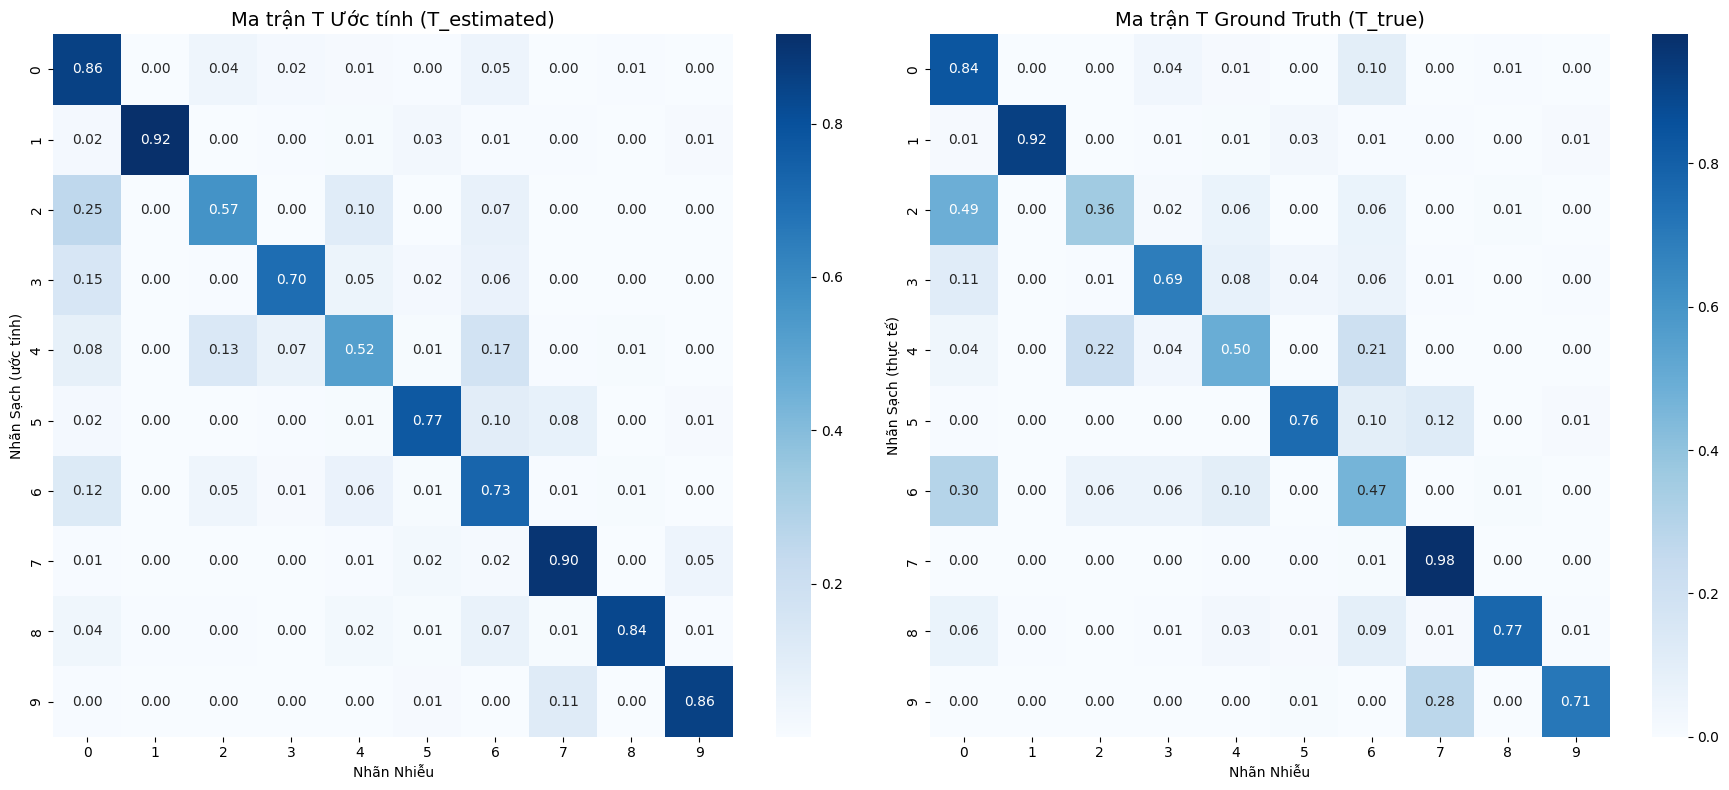


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.6537
Epoch [2/100], Correction Loss: 0.6459
Epoch [3/100], Correction Loss: 0.6455
Epoch [4/100], Correction Loss: 0.6422
Epoch [5/100], Correction Loss: 0.6396
Epoch [6/100], Correction Loss: 0.6415
Epoch [7/100], Correction Loss: 0.6384
Epoch [8/100], Correction Loss: 0.6402
Epoch [9/100], Correction Loss: 0.6363
Epoch [10/100], Correction Loss: 0.6406
Epoch [11/100], Correction Loss: 0.6367
Epoch [12/100], Correction Loss: 0.6356
Epoch [13/100], Correction Loss: 0.6353
Epoch [14/100], Correction Loss: 0.6338
Epoch [15/100], Correction Loss: 0.6316
Epoch [16/100], Correction Loss: 0.6292
Epoch [17/100], Correction Loss: 0.6289
Epoch [18/100], Correction Loss: 0.6292
Epoch [19/100], Correction Loss: 0.6323
Epoch [20/100], Correction Loss: 0.6317
Epoch [21/100], Correction Loss: 0.6312
Epoch [22/100], Correction Loss: 0.6302
Epoch [23/100], Correction Loss: 0.6316


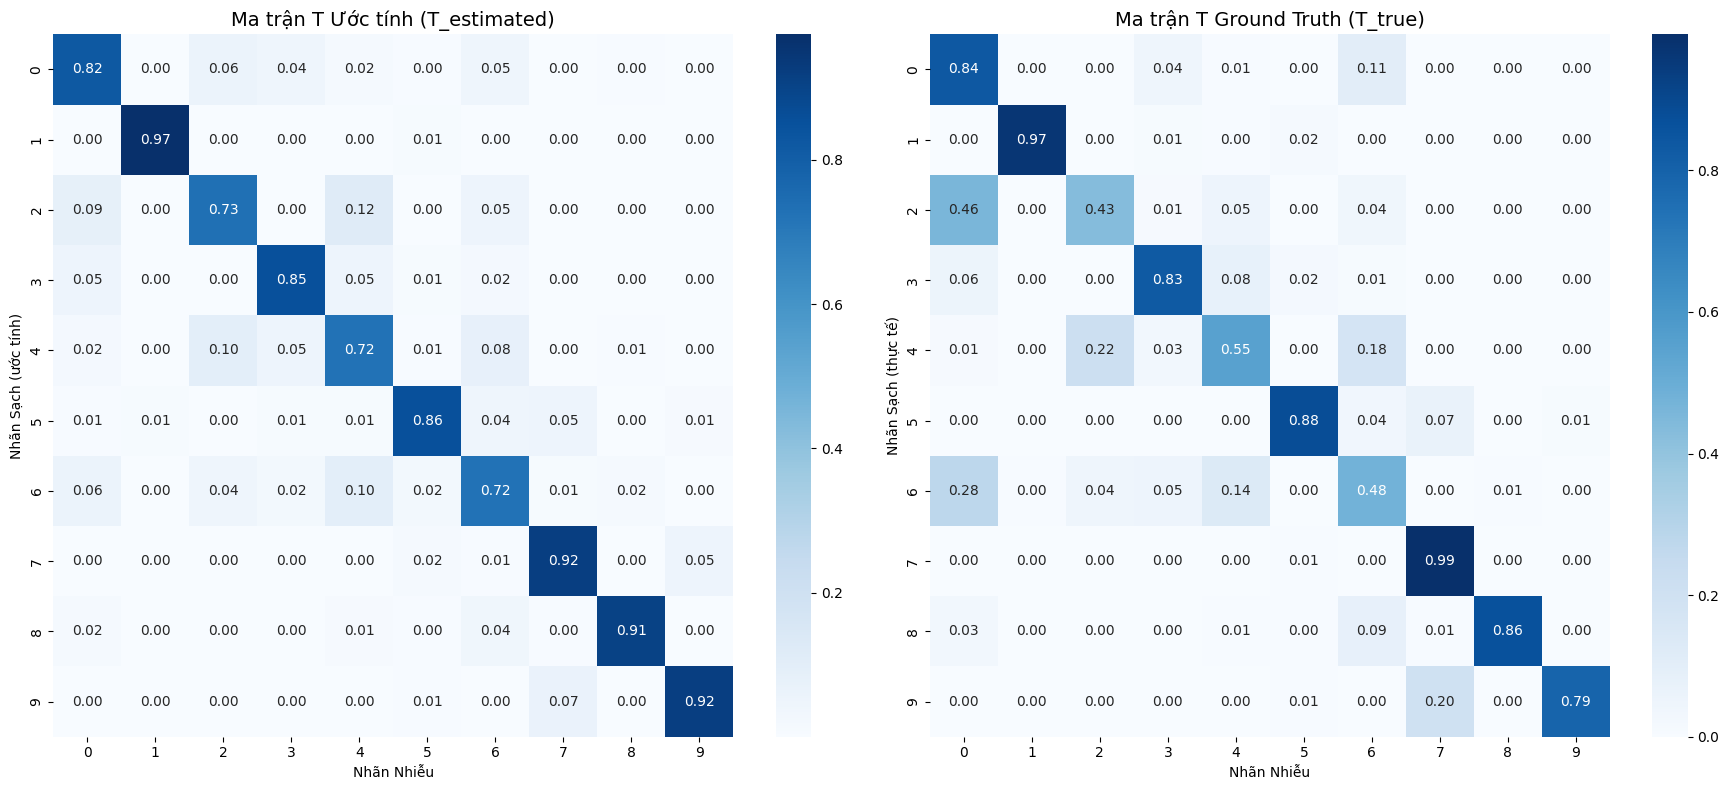


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1922
Epoch [2/100], Correction Loss: 0.1843
Epoch [3/100], Correction Loss: 0.1831
Epoch [4/100], Correction Loss: 0.1822
Epoch [5/100], Correction Loss: 0.1807
Epoch [6/100], Correction Loss: 0.1802
Epoch [7/100], Correction Loss: 0.1799
Epoch [8/100], Correction Loss: 0.1796
Epoch [9/100], Correction Loss: 0.1797
Epoch [10/100], Correction Loss: 0.1798
Epoch [11/100], Correction Loss: 0.1794
Epoch [12/100], Correction Loss: 0.1788
Epoch [13/100], Correction Loss: 0.1772
Epoch [14/100], Correction Loss: 0.1768
Epoch [15/100], Correction Loss: 0.1774
Epoch [16/100], Correction Loss: 0.1782
Epoch [17/100], Correction Loss: 0.1770
Epoch [18/100], Correction Loss: 0.1779
Epoch [19/100], Correction Loss: 0.1776
Epoch [20/100], Correction Loss: 0.1765
Epoch [21/100], Correction Loss: 0.1768
Epoch [22/100], Correction Loss: 0.1735
Epoch [23/100], Correction Loss: 0.1771


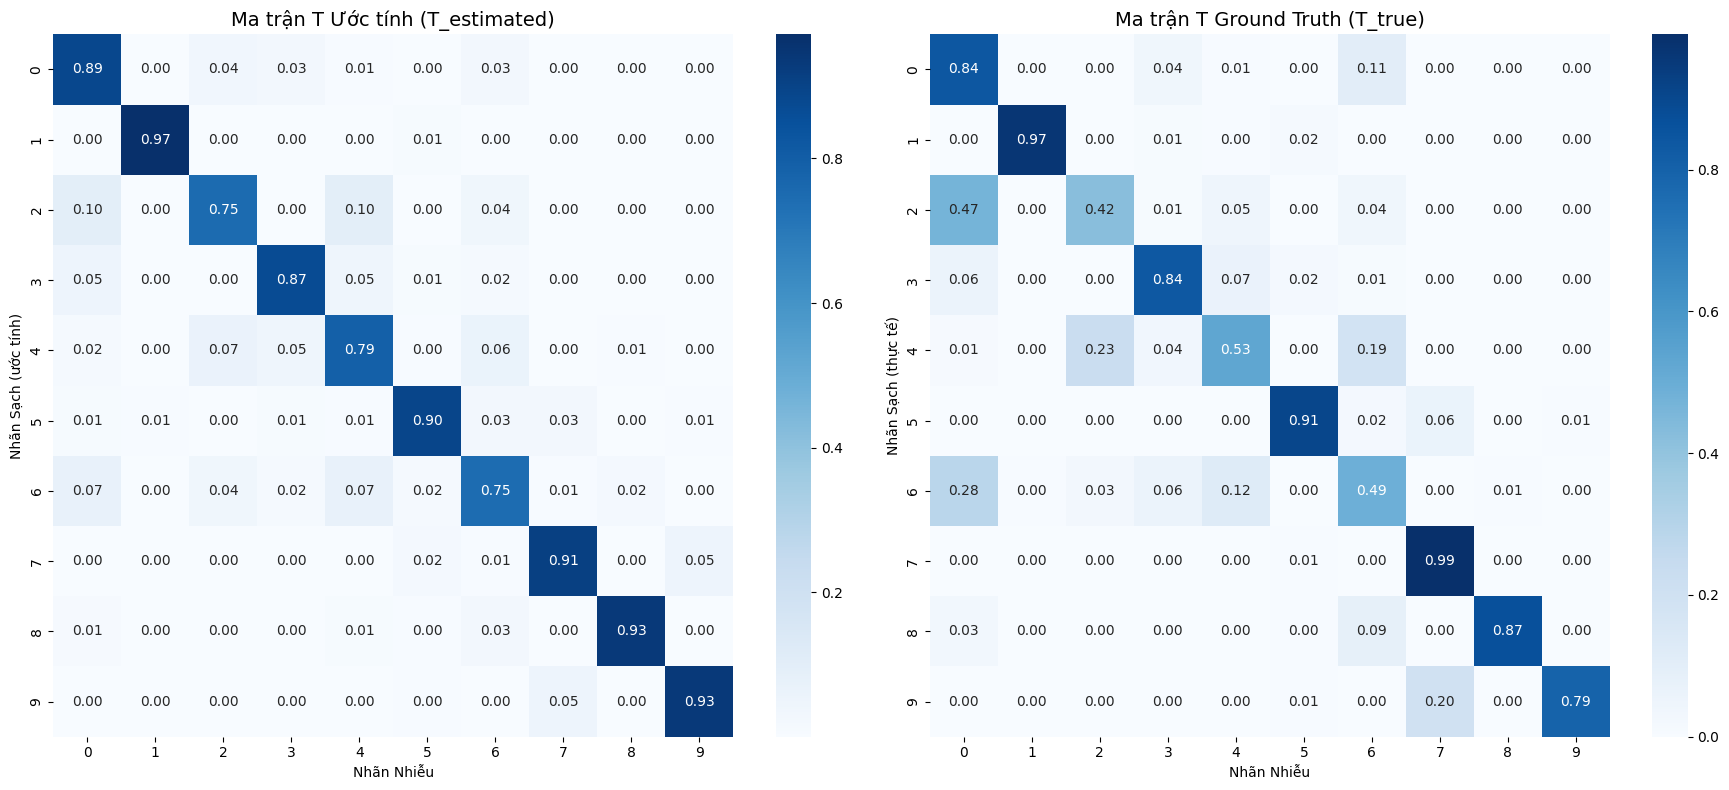


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1460
Epoch [2/100], Correction Loss: 0.1371
Epoch [3/100], Correction Loss: 0.1348
Epoch [4/100], Correction Loss: 0.1339
Epoch [5/100], Correction Loss: 0.1330
Epoch [6/100], Correction Loss: 0.1337
Epoch [7/100], Correction Loss: 0.1331
Epoch [8/100], Correction Loss: 0.1329
Epoch [9/100], Correction Loss: 0.1329
Epoch [10/100], Correction Loss: 0.1329
Epoch [11/100], Correction Loss: 0.1313
Epoch [12/100], Correction Loss: 0.1302
Epoch [13/100], Correction Loss: 0.1306
Epoch [14/100], Correction Loss: 0.1307
Epoch [15/100], Correction Loss: 0.1313
Epoch [16/100], Correction Loss: 0.1305
Epoch [17/100], Correction Loss: 0.1296
Epoch [18/100], Correction Loss: 0.1308
Epoch [19/100], Correction Loss: 0.1302
Epoch [20/100], Correction Loss: 0.1283
Epoch [21/100], Correction Loss: 0.1302
Epoch [22/100], Correction Loss: 0.1298
Epoch [23/100], Correction Loss: 0.1282


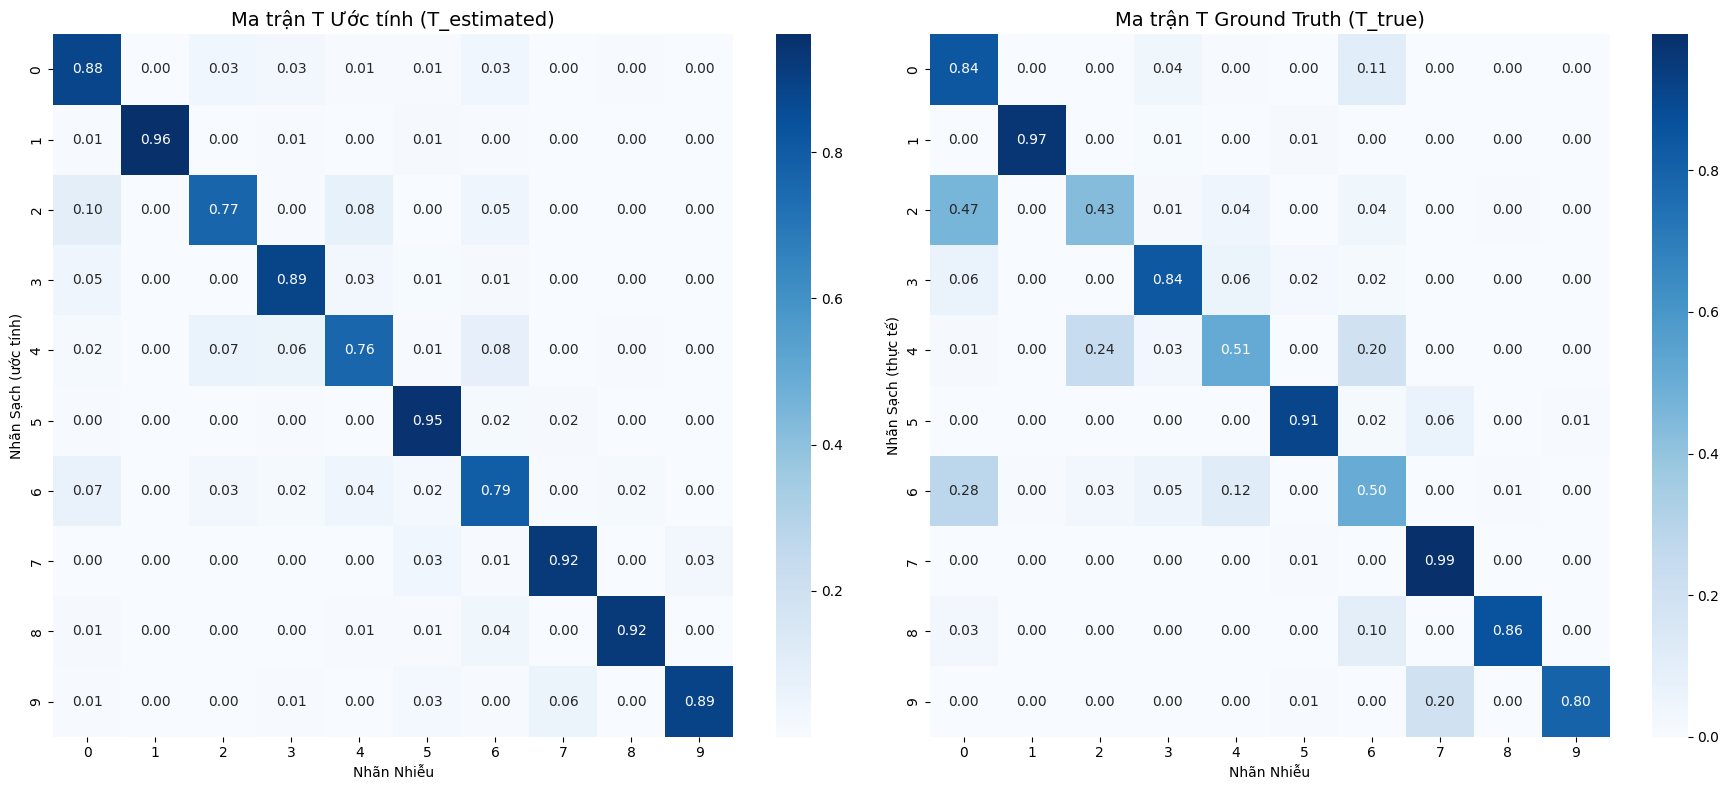


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1535
Epoch [2/100], Correction Loss: 0.1394
Epoch [3/100], Correction Loss: 0.1354
Epoch [4/100], Correction Loss: 0.1349
Epoch [5/100], Correction Loss: 0.1350
Epoch [6/100], Correction Loss: 0.1340
Epoch [7/100], Correction Loss: 0.1315
Epoch [8/100], Correction Loss: 0.1317
Epoch [9/100], Correction Loss: 0.1327
Epoch [10/100], Correction Loss: 0.1332
Epoch [11/100], Correction Loss: 0.1322
Epoch [12/100], Correction Loss: 0.1309
Epoch [13/100], Correction Loss: 0.1305
Epoch [14/100], Correction Loss: 0.1321
Epoch [15/100], Correction Loss: 0.1314
Epoch [16/100], Correction Loss: 0.1301
Epoch [17/100], Correction Loss: 0.1310
Epoch [18/100], Correction Loss: 0.1308
Epoch [19/100], Correction Loss: 0.1293
Epoch [20/100], Correction Loss: 0.1284
Epoch [21/100], Correction Loss: 0.1295
Epoch [22/100], Correction Loss: 0.1284
Epoch [23/100], Correction Loss: 0.1312


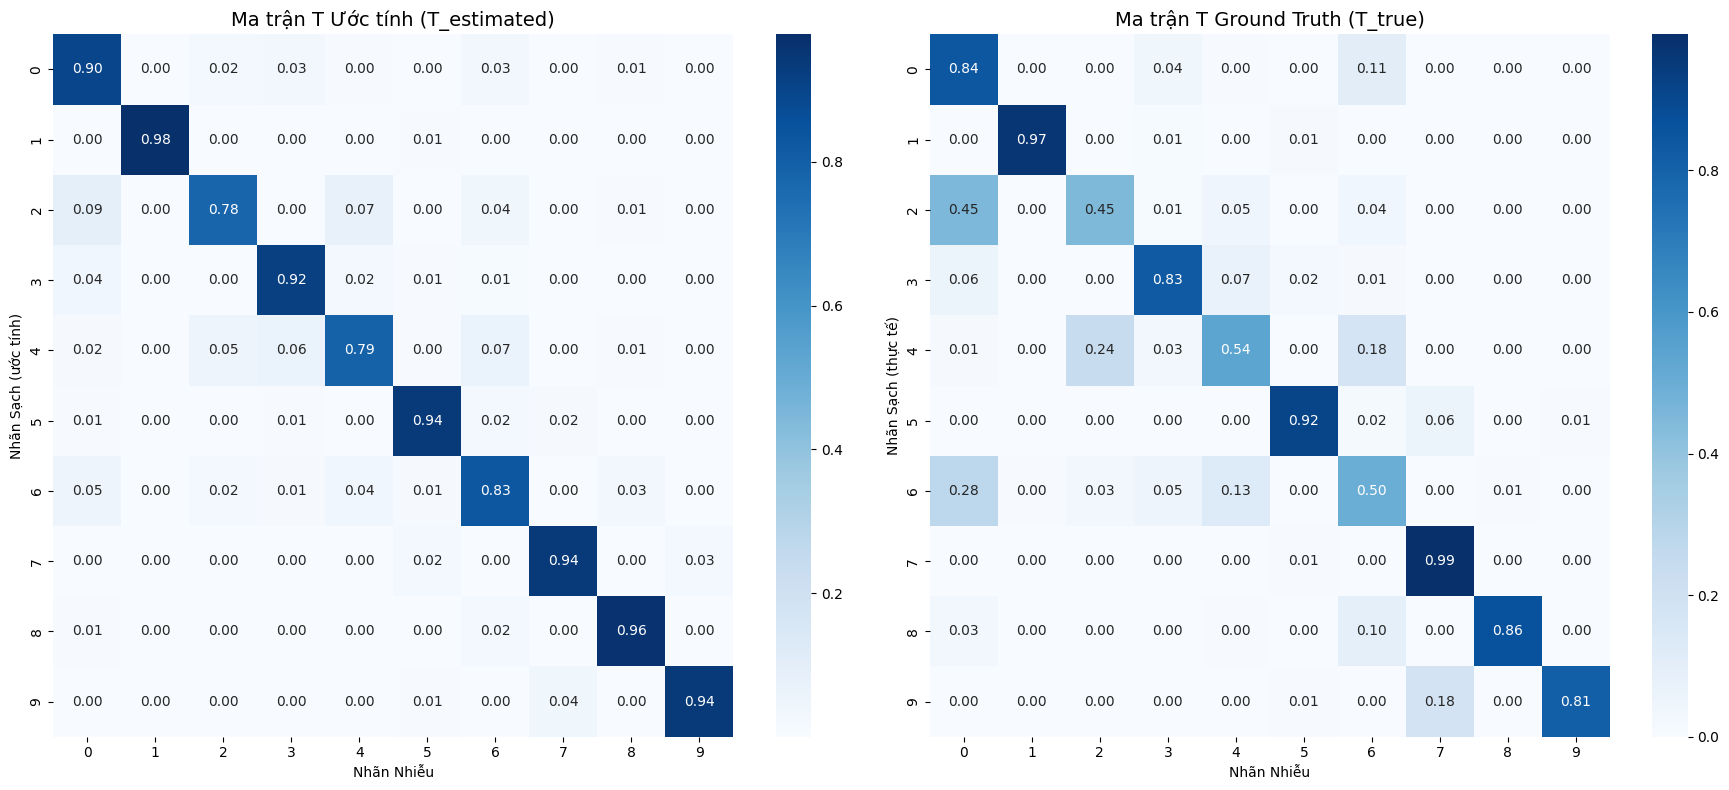


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1331
Epoch [2/100], Correction Loss: 0.1226
Epoch [3/100], Correction Loss: 0.1206
Epoch [4/100], Correction Loss: 0.1176
Epoch [5/100], Correction Loss: 0.1177
Epoch [6/100], Correction Loss: 0.1158
Epoch [7/100], Correction Loss: 0.1171
Epoch [8/100], Correction Loss: 0.1170
Epoch [9/100], Correction Loss: 0.1153
Epoch [10/100], Correction Loss: 0.1170
Epoch [11/100], Correction Loss: 0.1162
Epoch [12/100], Correction Loss: 0.1166
Epoch [13/100], Correction Loss: 0.1158
Epoch [14/100], Correction Loss: 0.1139
Epoch [15/100], Correction Loss: 0.1167
Epoch [16/100], Correction Loss: 0.1182
Epoch [17/100], Correction Loss: 0.1158
Epoch [18/100], Correction Loss: 0.1147
Epoch [19/100], Correction Loss: 0.1159
Epoch [20/100], Correction Loss: 0.1138
Epoch [21/100], Correction Loss: 0.1133
Epoch [22/100], Correction Loss: 0.1141
Epoch [23/100], Correction Loss: 0.1125


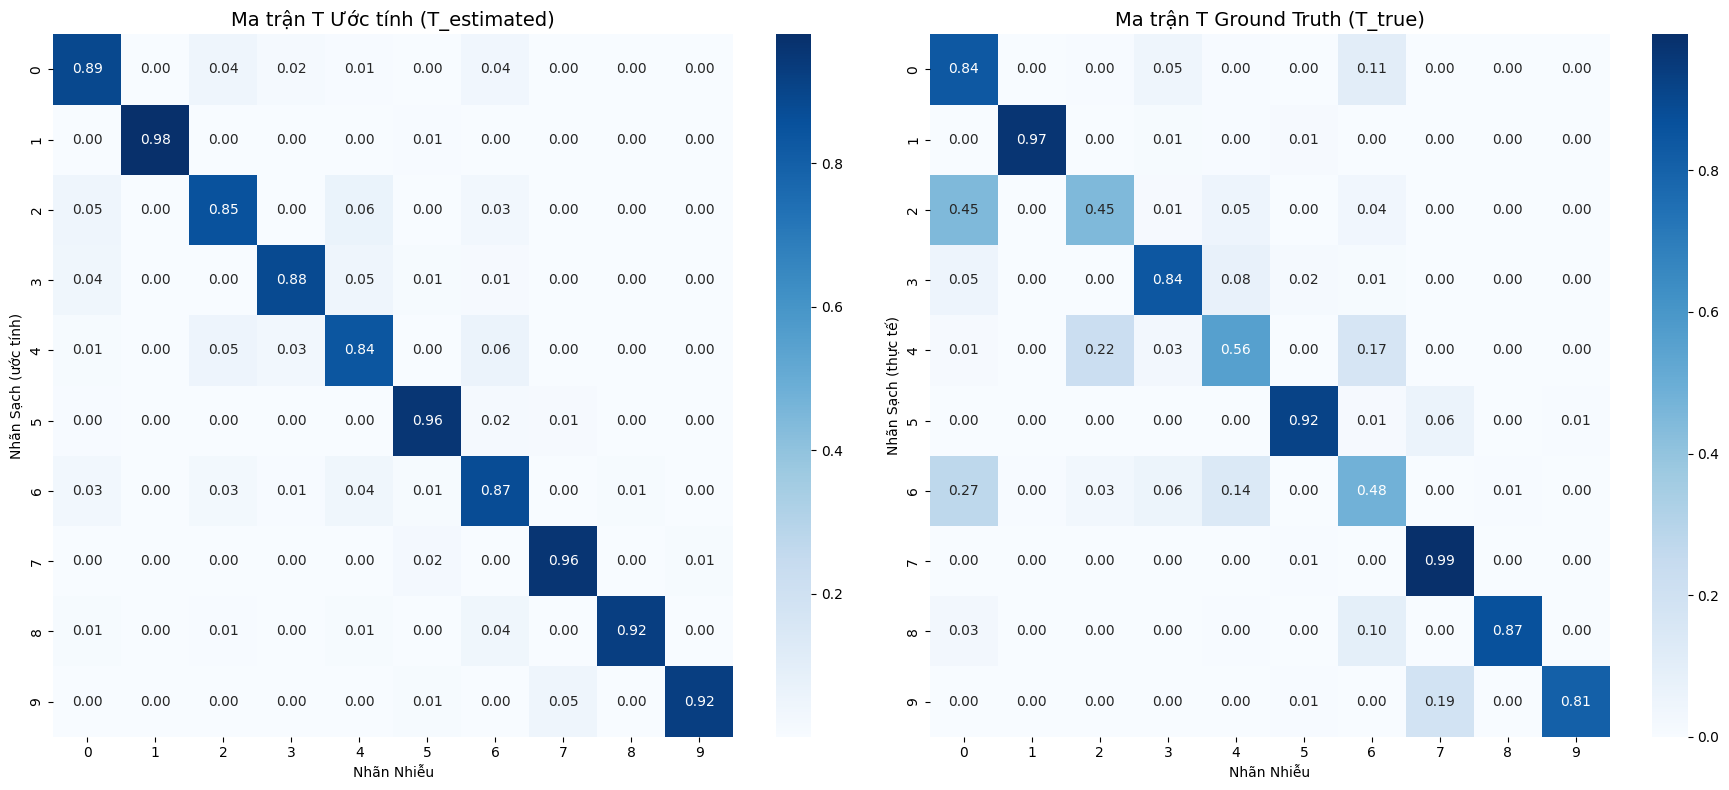


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1240
Epoch [2/100], Correction Loss: 0.1125
Epoch [3/100], Correction Loss: 0.1079
Epoch [4/100], Correction Loss: 0.1079
Epoch [5/100], Correction Loss: 0.1079
Epoch [6/100], Correction Loss: 0.1092
Epoch [7/100], Correction Loss: 0.1062
Epoch [8/100], Correction Loss: 0.1057
Epoch [9/100], Correction Loss: 0.1075
Epoch [10/100], Correction Loss: 0.1075
Epoch [11/100], Correction Loss: 0.1064
Epoch [12/100], Correction Loss: 0.1060
Epoch [13/100], Correction Loss: 0.1050
Epoch [14/100], Correction Loss: 0.1039
Epoch [15/100], Correction Loss: 0.1067
Epoch [16/100], Correction Loss: 0.1070
Epoch [17/100], Correction Loss: 0.1067
Epoch [18/100], Correction Loss: 0.1043
Epoch [19/100], Correction Loss: 0.1054
Epoch [20/100], Correction Loss: 0.1050
Epoch [21/100], Correction Loss: 0.1055
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy 

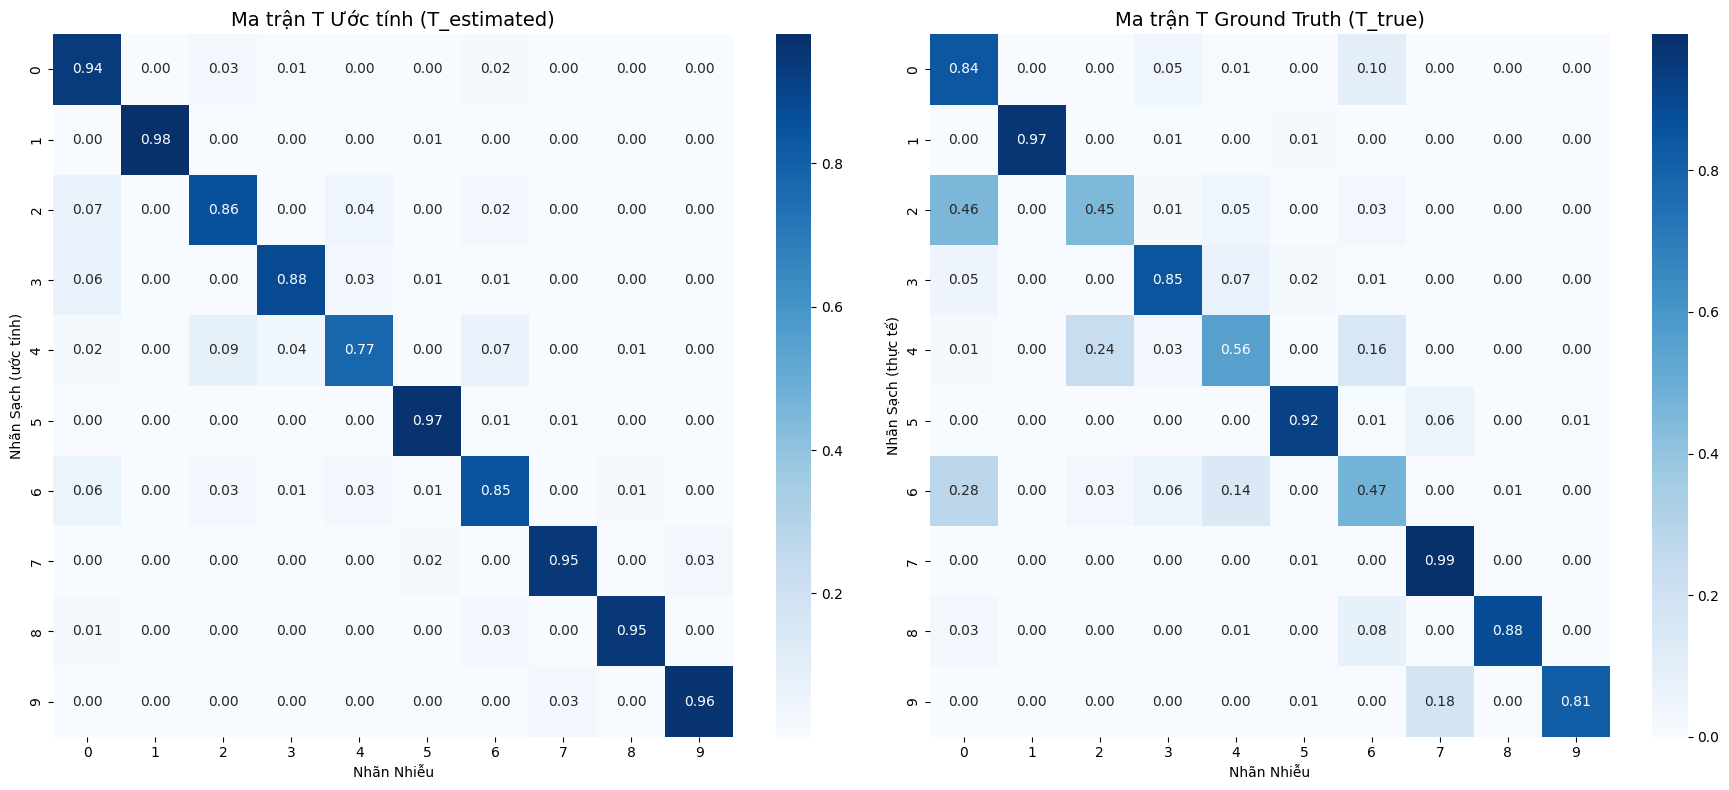


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1224
Epoch [2/100], Correction Loss: 0.1098
Epoch [3/100], Correction Loss: 0.1068
Epoch [4/100], Correction Loss: 0.1063
Epoch [5/100], Correction Loss: 0.1061
Epoch [6/100], Correction Loss: 0.1057
Epoch [7/100], Correction Loss: 0.1047
Epoch [8/100], Correction Loss: 0.1044
Epoch [9/100], Correction Loss: 0.1029
Epoch [10/100], Correction Loss: 0.1035
Epoch [11/100], Correction Loss: 0.1015
Epoch [12/100], Correction Loss: 0.1029
Epoch [13/100], Correction Loss: 0.1031
Epoch [14/100], Correction Loss: 0.1029
Epoch [15/100], Correction Loss: 0.1047
Epoch [16/100], Correction Loss: 0.1021
Epoch [17/100], Correction Loss: 0.1023
Epoch [18/100], Correction Loss: 0.1021
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---

📊 Đánh giá cuối vòng lặp 7:
   - Correction Loss tổng thể: 0.1021
🎉 Cải thiện 

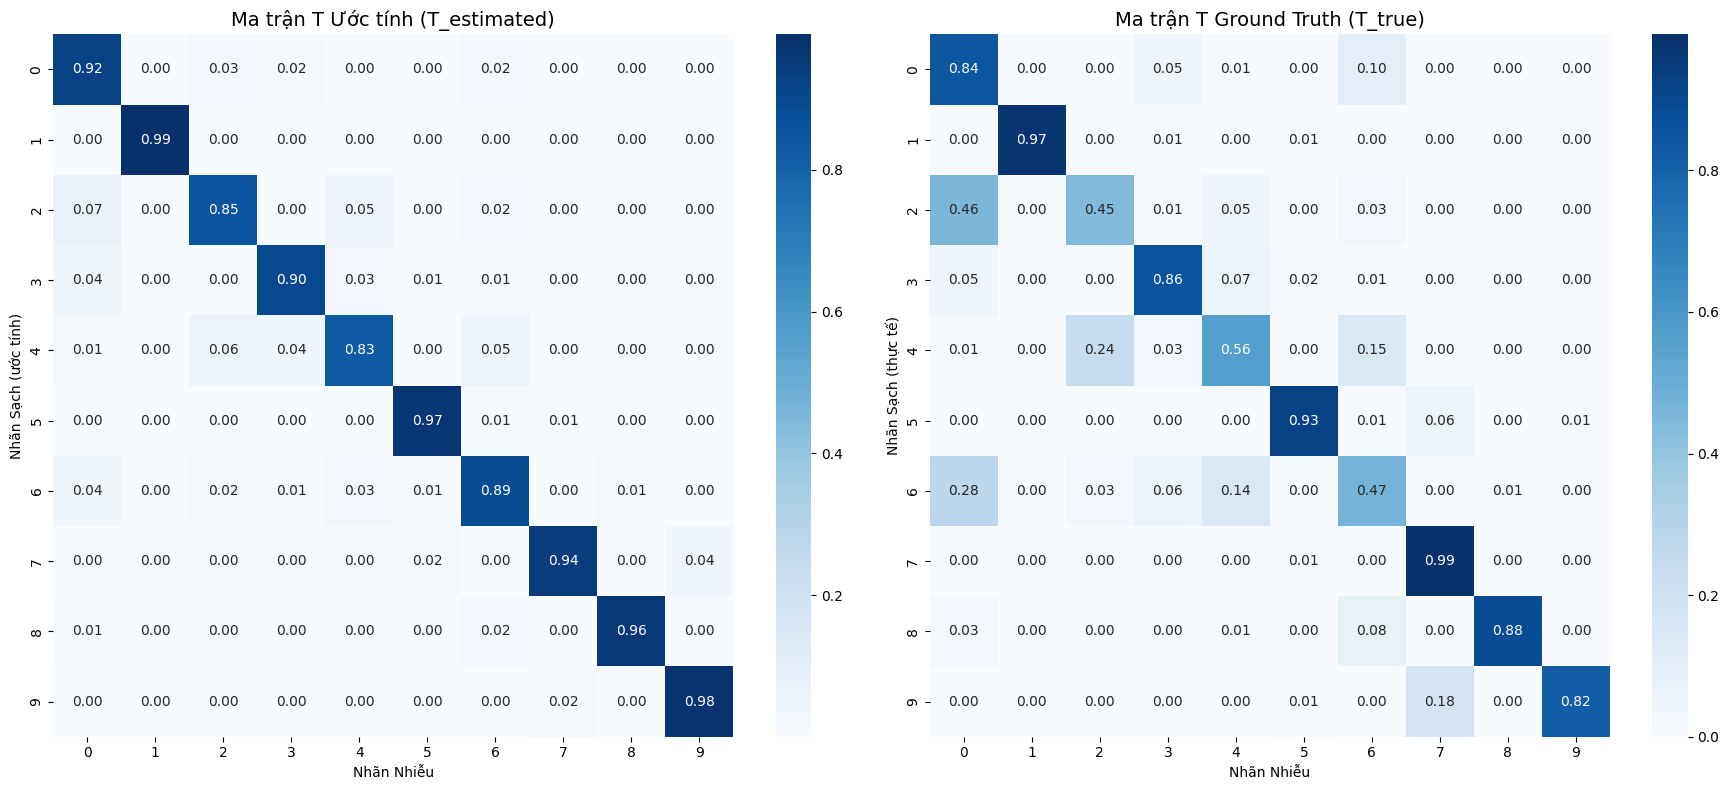


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1049
Epoch [2/100], Correction Loss: 0.0932
Epoch [3/100], Correction Loss: 0.0911
Epoch [4/100], Correction Loss: 0.0906
Epoch [5/100], Correction Loss: 0.0894
Epoch [6/100], Correction Loss: 0.0876
Epoch [7/100], Correction Loss: 0.0886
Epoch [8/100], Correction Loss: 0.0884
Epoch [9/100], Correction Loss: 0.0883
Epoch [10/100], Correction Loss: 0.0891
Epoch [11/100], Correction Loss: 0.0865
Epoch [12/100], Correction Loss: 0.0878
Epoch [13/100], Correction Loss: 0.0882
Epoch [14/100], Correction Loss: 0.0873
Epoch [15/100], Correction Loss: 0.0874
Epoch [16/100], Correction Loss: 0.0888
Epoch [17/100], Correction Loss: 0.0875
Epoch [18/100], Correction Loss: 0.0865
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---

📊 Đánh giá cuối vòng lặp 8:
   - Correction Loss tổng thể: 0.0865
🎉 Cải thiện 

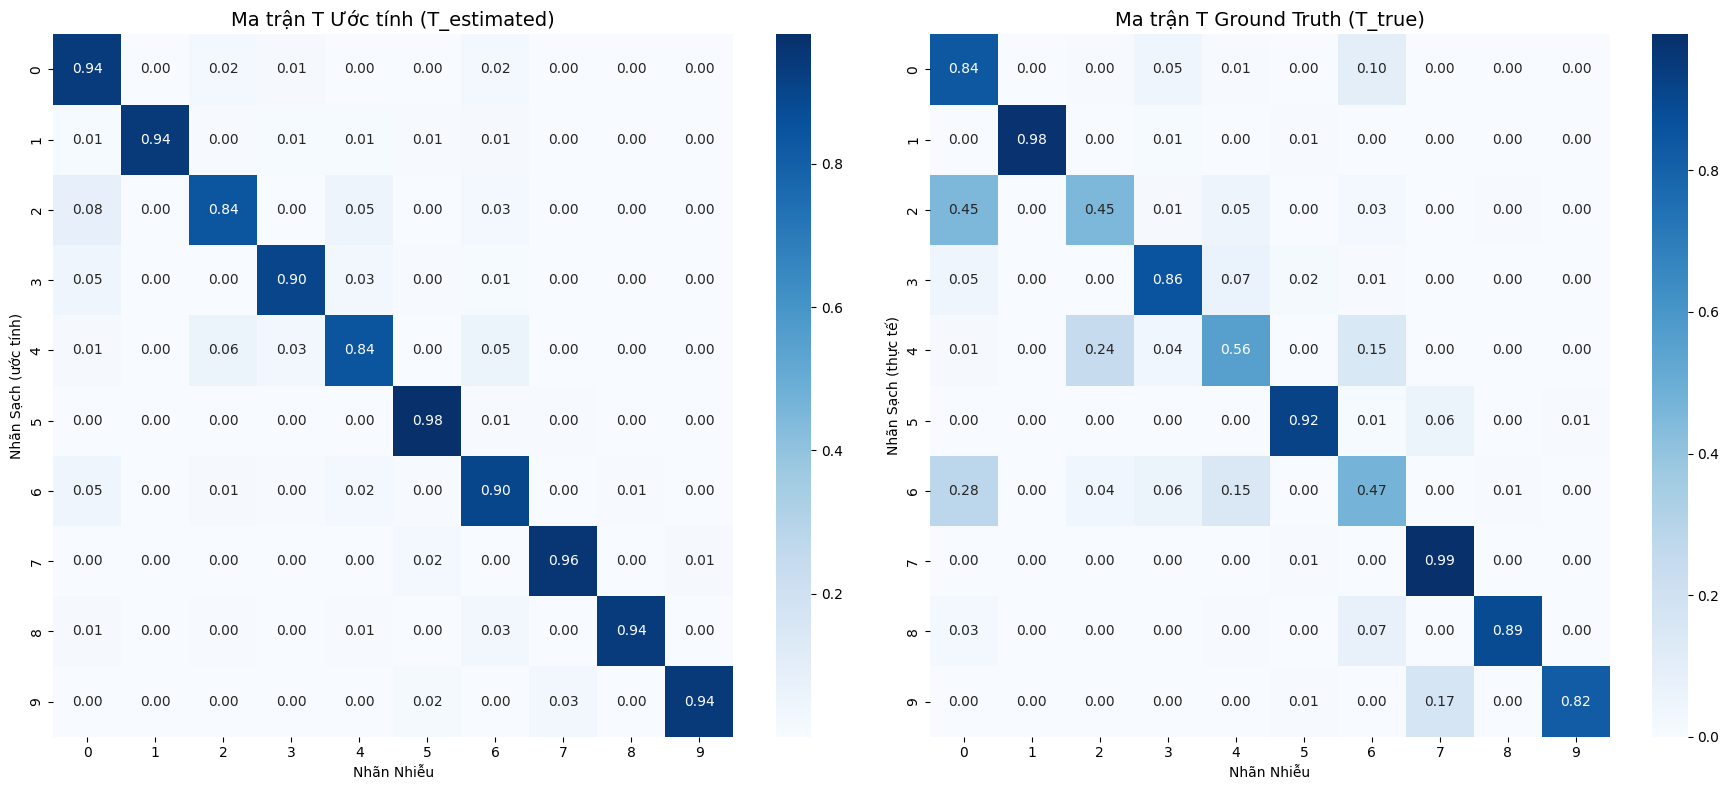


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1074
Epoch [2/100], Correction Loss: 0.0994
Epoch [3/100], Correction Loss: 0.0946
Epoch [4/100], Correction Loss: 0.0937
Epoch [5/100], Correction Loss: 0.0920
Epoch [6/100], Correction Loss: 0.0927
Epoch [7/100], Correction Loss: 0.0907
Epoch [8/100], Correction Loss: 0.0929
Epoch [9/100], Correction Loss: 0.0911
Epoch [10/100], Correction Loss: 0.0883
Epoch [11/100], Correction Loss: 0.0908
Epoch [12/100], Correction Loss: 0.0914
Epoch [13/100], Correction Loss: 0.0917
Epoch [14/100], Correction Loss: 0.0899
Epoch [15/100], Correction Loss: 0.0884
Epoch [16/100], Correction Loss: 0.0902
Epoch [17/100], Correction Loss: 0.0904
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---

📊 Đánh giá cuối vòng lặp 9:
   - Correction Loss tổng thể: 0.0904
📉 Không cải thiện loss. Patience: 1/3

🔄 Cập nhật so

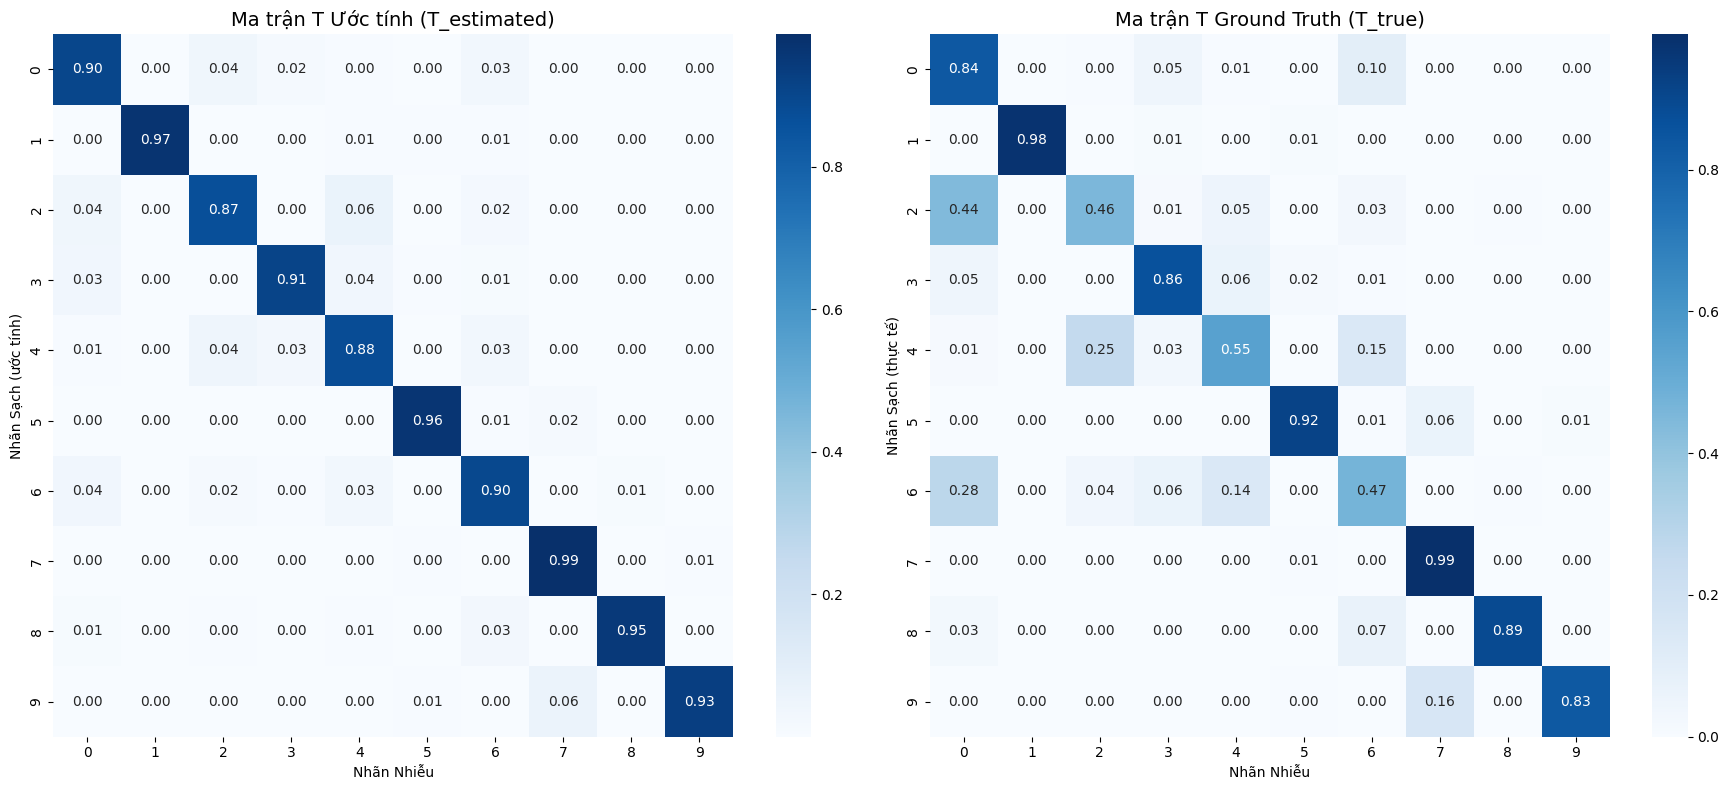


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1086
Epoch [2/100], Correction Loss: 0.0978
Epoch [3/100], Correction Loss: 0.0951
Epoch [4/100], Correction Loss: 0.0929
Epoch [5/100], Correction Loss: 0.0931
Epoch [6/100], Correction Loss: 0.0930
Epoch [7/100], Correction Loss: 0.0905
Epoch [8/100], Correction Loss: 0.0922
Epoch [9/100], Correction Loss: 0.0899
Epoch [10/100], Correction Loss: 0.0931
Epoch [11/100], Correction Loss: 0.0915
Epoch [12/100], Correction Loss: 0.0896
Epoch [13/100], Correction Loss: 0.0893
Epoch [14/100], Correction Loss: 0.0901
Epoch [15/100], Correction Loss: 0.0890
Epoch [16/100], Correction Loss: 0.0891
Epoch [17/100], Correction Loss: 0.0893
Epoch [18/100], Correction Loss: 0.0887
Epoch [19/100], Correction Loss: 0.0897
Epoch [20/100], Correction Loss: 0.0899
Epoch [21/100], Correction Loss: 0.0892
Epoch [22/100], Correction Loss: 0.0888
Epoch [23/100], Correction Loss: 0.0888


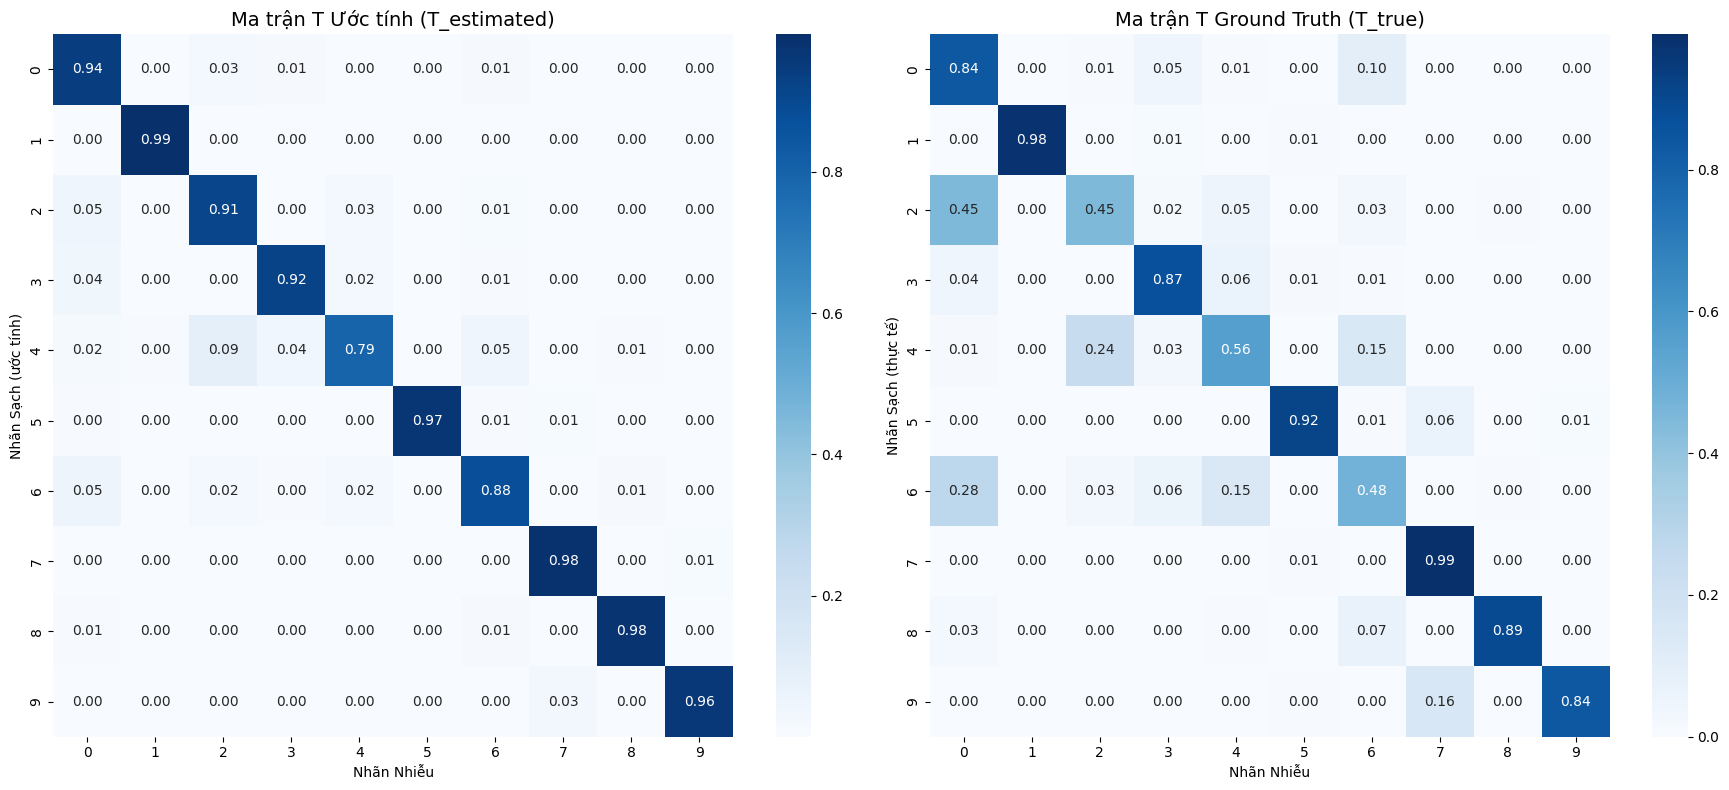


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.0927
Epoch [2/100], Correction Loss: 0.0840
Epoch [3/100], Correction Loss: 0.0815
Epoch [4/100], Correction Loss: 0.0806
Epoch [5/100], Correction Loss: 0.0784
Epoch [6/100], Correction Loss: 0.0777
Epoch [7/100], Correction Loss: 0.0781
Epoch [8/100], Correction Loss: 0.0808
Epoch [9/100], Correction Loss: 0.0796
Epoch [10/100], Correction Loss: 0.0783
Epoch [11/100], Correction Loss: 0.0801
Epoch [12/100], Correction Loss: 0.0797
Epoch [13/100], Correction Loss: 0.0772
Epoch [14/100], Correction Loss: 0.0779
Epoch [15/100], Correction Loss: 0.0786
Epoch [16/100], Correction Loss: 0.0774
Epoch [17/100], Correction Loss: 0.0772
Epoch [18/100], Correction Loss: 0.0765
Epoch [19/100], Correction Loss: 0.0776
Epoch [20/100], Correction Loss: 0.0767
Epoch [21/100], Correction Loss: 0.0786
Epoch [22/100], Correction Loss: 0.0768
Epoch [23/100], Correction Loss: 0.0783


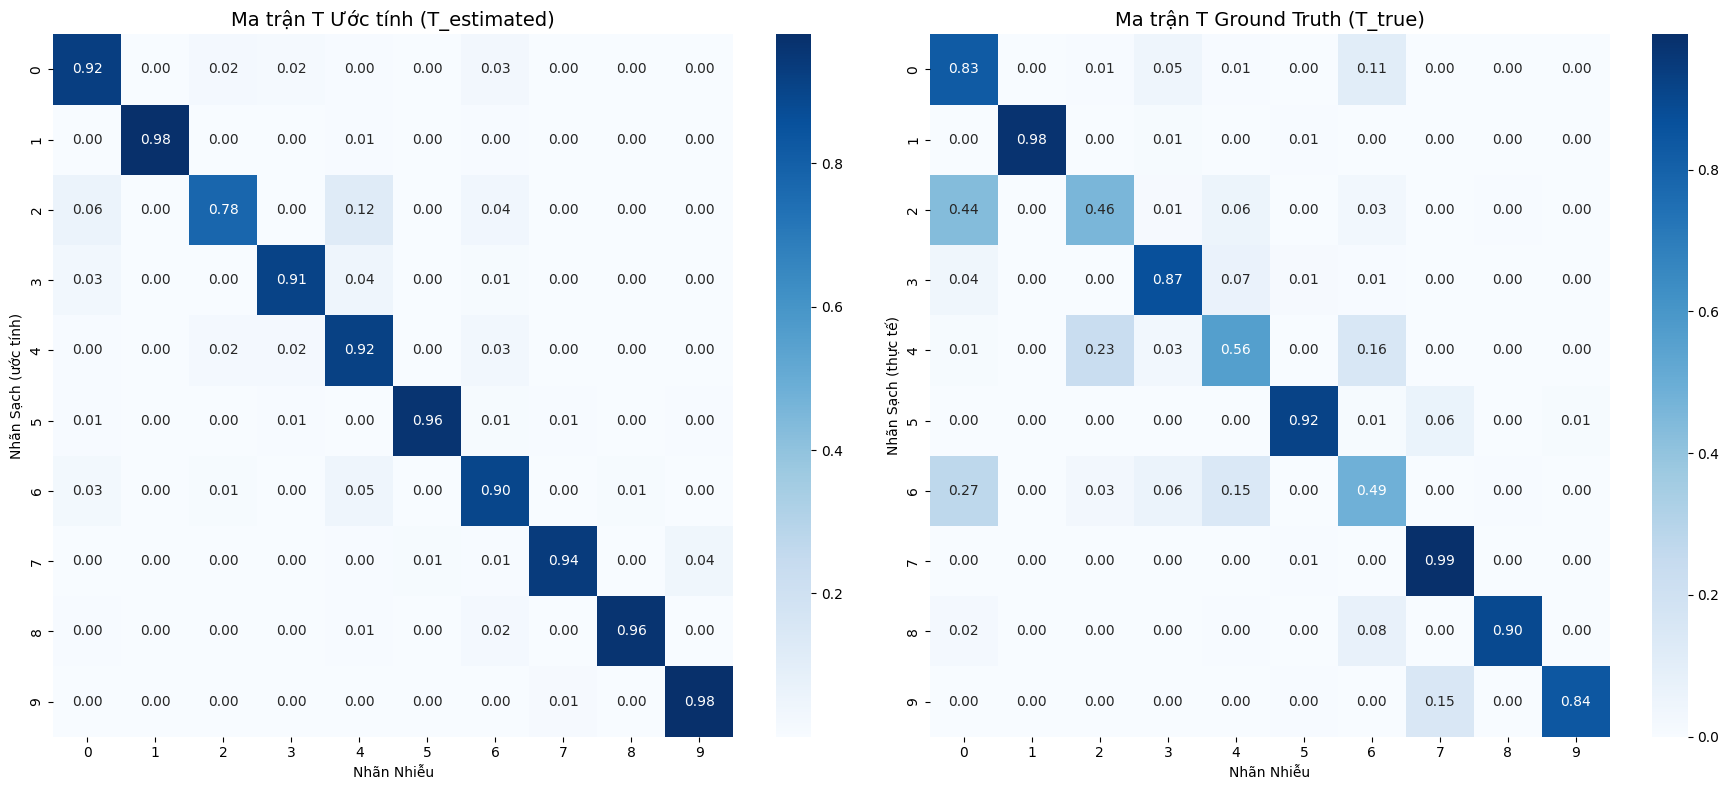


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1155
Epoch [2/100], Correction Loss: 0.1037
Epoch [3/100], Correction Loss: 0.0990
Epoch [4/100], Correction Loss: 0.0973
Epoch [5/100], Correction Loss: 0.0954
Epoch [6/100], Correction Loss: 0.0969
Epoch [7/100], Correction Loss: 0.0963
Epoch [8/100], Correction Loss: 0.0970
Epoch [9/100], Correction Loss: 0.0950
Epoch [10/100], Correction Loss: 0.0944
Epoch [11/100], Correction Loss: 0.0926
Epoch [12/100], Correction Loss: 0.0947
Epoch [13/100], Correction Loss: 0.0975
Epoch [14/100], Correction Loss: 0.0947
Epoch [15/100], Correction Loss: 0.0942
Epoch [16/100], Correction Loss: 0.0940
Epoch [17/100], Correction Loss: 0.0919
Epoch [18/100], Correction Loss: 0.0917
Epoch [19/100], Correction Loss: 0.0933
Epoch [20/100], Correction Loss: 0.0918
Epoch [21/100], Correction Loss: 0.0959
Epoch [22/100], Correction Loss: 0.0911
Epoch [23/100], Correction Loss: 0.0936


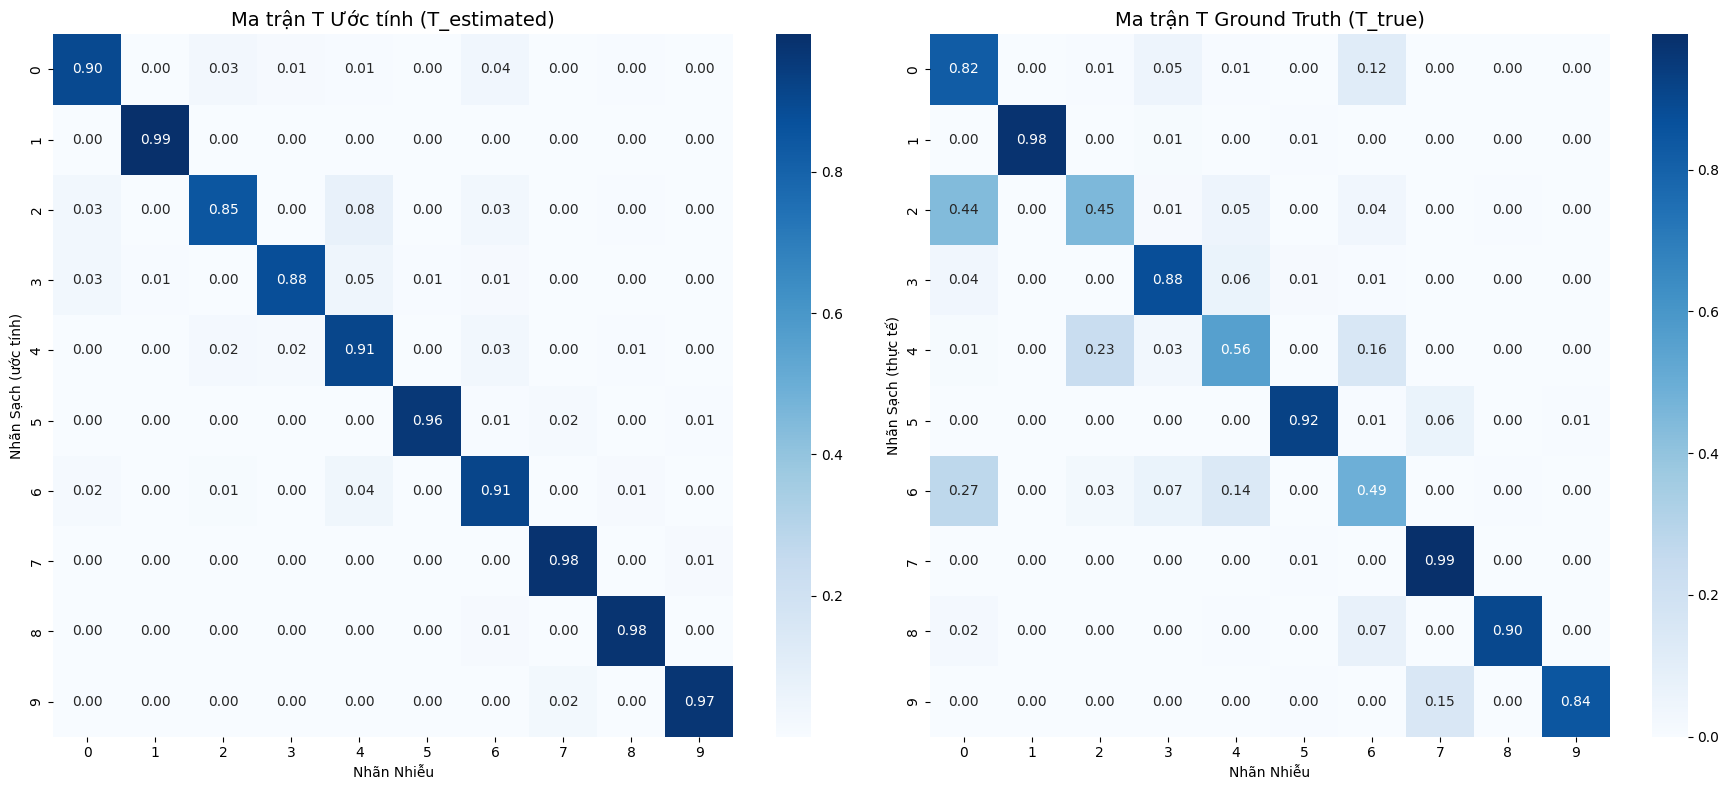


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1060
Epoch [2/100], Correction Loss: 0.0954
Epoch [3/100], Correction Loss: 0.0904
Epoch [4/100], Correction Loss: 0.0884
Epoch [5/100], Correction Loss: 0.0876
Epoch [6/100], Correction Loss: 0.0893
Epoch [7/100], Correction Loss: 0.0901
Epoch [8/100], Correction Loss: 0.0889
Epoch [9/100], Correction Loss: 0.0852
Epoch [10/100], Correction Loss: 0.0884
Epoch [11/100], Correction Loss: 0.0868
Epoch [12/100], Correction Loss: 0.0859
Epoch [13/100], Correction Loss: 0.0873
Epoch [14/100], Correction Loss: 0.0876
Epoch [15/100], Correction Loss: 0.0880
Epoch [16/100], Correction Loss: 0.0872
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---

📊 Đánh giá cuối vòng lặp 13:
   - Correction Loss tổng thể: 0.0872
📉 Không cải thiện loss. Patience: 2/3

🔄 Cập nhật soft labels cho vòng lặp tiếp theo...
✅ S

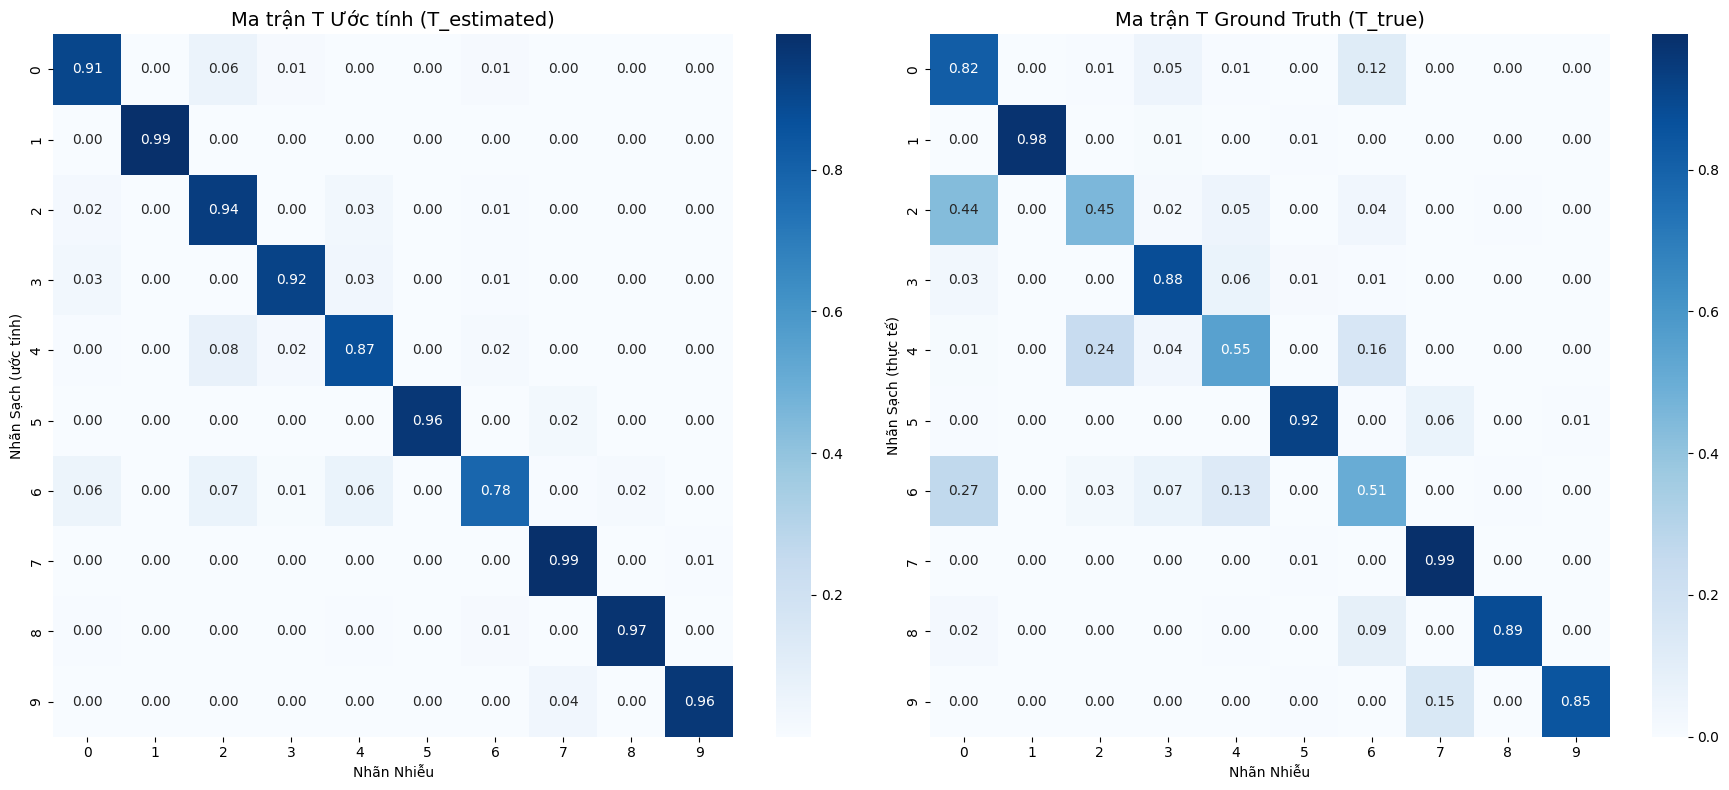


--- Phase 2. Fine-tune model ---
Bắt đầu fine-tune model rtm trong tối đa 100 epochs...
Epoch [1/100], Correction Loss: 0.1089
Epoch [2/100], Correction Loss: 0.0977
Epoch [3/100], Correction Loss: 0.0930
Epoch [4/100], Correction Loss: 0.0935
Epoch [5/100], Correction Loss: 0.0916
Epoch [6/100], Correction Loss: 0.0903
Epoch [7/100], Correction Loss: 0.0898
Epoch [8/100], Correction Loss: 0.0921
Epoch [9/100], Correction Loss: 0.0915
Epoch [10/100], Correction Loss: 0.0920
Epoch [11/100], Correction Loss: 0.0878
Epoch [12/100], Correction Loss: 0.0904
Epoch [13/100], Correction Loss: 0.0924
Epoch [14/100], Correction Loss: 0.0900
Epoch [15/100], Correction Loss: 0.0890
Epoch [16/100], Correction Loss: 0.0912
Epoch [17/100], Correction Loss: 0.0889
Epoch [18/100], Correction Loss: 0.0894
🛑 Dừng sớm! Loss không cải thiện trong 7 epochs.
✅ Fine-tune hoàn tất.

--- Lấy nhãn mềm đã sửa từ vòng lặp hiện tại ---

📊 Đánh giá cuối vòng lặp 14:
   - Correction Loss tổng thể: 0.0894
📉 Không cải

In [12]:
# --- Bắt đầu quy trình ---
set_seed(config['SEED'])

# 1. Khởi tạo và chạy pipeline lặp lại
pipeline = NoiseCorrectionPipeline(config)

# noisy_labels ở đây là nhãn nhiễu ban đầu
corrected_labels, true_labels, noisy_labels = pipeline.run()

# 2. ĐÁNH GIÁ KẾT QUẢ CUỐI CÙNG
print("\n" + "="*50)
print("--- ĐÁNH GIÁ KẾT QUẢ CUỐI CÙNG ---")
print("="*50 + "\n")

class_names = [str(i) for i in range(len(np.unique(true_labels)))]

# Chất lượng bộ dữ liệu TRƯỚC và SAU khi sửa lỗi
print("\n--- 2.2. Chất lượng bộ dữ liệu TRƯỚC và SAU khi sửa lỗi ---")
acc_original = accuracy_score(true_labels, noisy_labels)
noise_rate_original = 1 - acc_original
acc_corrected = accuracy_score(true_labels, corrected_labels)
noise_rate_corrected = 1 - acc_corrected
print(f"📈 Độ chính xác của bộ dữ liệu GỐC: {acc_original*100:.2f}%")
print(f"🔥 Tỷ lệ nhiễu (Noise Rate) GỐC: {noise_rate_original*100:.2f}%")
print("-" * 20)
print(f"📉 Độ chính xác của bộ dữ liệu SAU KHI SỬA (CUỐI CÙNG): {acc_corrected*100:.2f}%")
print(f"💧 Tỷ lệ nhiễu (Noise Rate) CÒN LẠI: {noise_rate_corrected*100:.2f}%")
print("-" * 50)